<a href="https://colab.research.google.com/github/regisoliveiragx-rgb/Fonte-de-informa-o-e-banco-de-dados/blob/main/AnalisedadosVendasSorvetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [14]:
import os
import pandas as pd

# List contents of the downloaded dataset directory
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# We'll try to find a CSV file and load it.

Files in dataset directory: ['Ice Cream Sales - temperatures.csv']


In [15]:
# Identify the CSV file (assuming there's only one or it's clearly named)
csv_files = [f for f in file_list if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the correct one
    df_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(df_path)
    print(f"Successfully loaded {csv_files[0]} into a DataFrame.")
    display(df.head(10))
else:
    print("No CSV file found in the dataset directory.")

Successfully loaded Ice Cream Sales - temperatures.csv into a DataFrame.


,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


In [16]:
print("Informações do DataFrame:")
df.info()

print("\nEstatísticas descritivas:")
display(df.describe())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        365 non-null    int64  
 1   Ice Cream Profits  365 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.8 KB

Estatísticas descritivas:


,Temperature,Ice Cream Profits
count,365.000000,365.000000
mean,71.980822,52.103616
std,13.258510,15.989004
min,39.000000,11.880000
25%,63.000000,40.650000
50%,73.000000,53.620000
75%,82.000000,63.630000
max,101.000000,89.290000


### Regressão Linear

Agora, vamos aplicar um modelo de regressão linear para entender a relação entre a temperatura e os lucros do sorvete.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir as variáveis X (recurso) e y (alvo)
X = df[['Temperature']].values  # Usar .values para obter um array numpy
y = df['Ice Cream Profits'].values

# Criar e treinar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Imprimir os coeficientes e o intercepto do modelo
print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")
print(f"(model.coef_[0]:.2f)x+{model.intercept_:.2f}")

Coeficiente (inclinação): 1.19
Intercepto: -33.70
(model.coef_[0]:.2f)x+-33.70


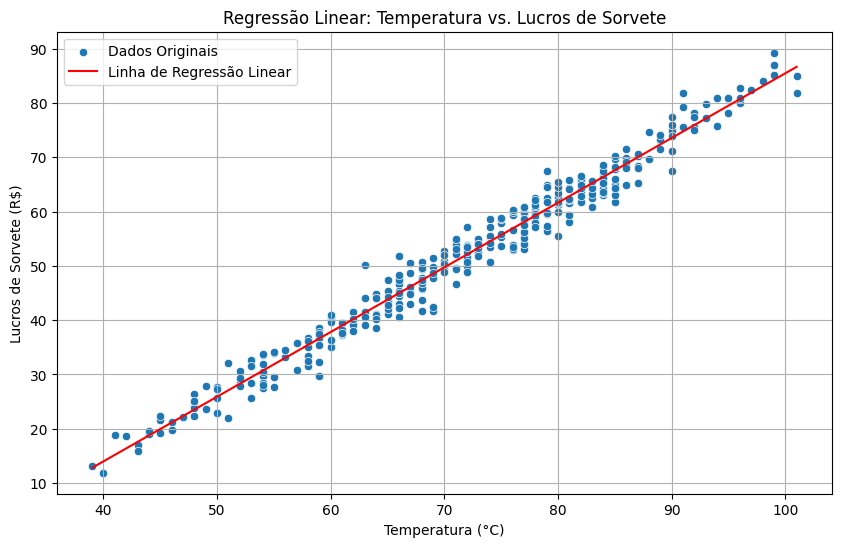

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar previsões
y_pred = model.predict(X)

# Plotar os dados e a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Temperature'], y=df['Ice Cream Profits'], label='Dados Originais')
plt.plot(df['Temperature'], y_pred, color='red', label='Linha de Regressão Linear')
plt.title('Regressão Linear: Temperatura vs. Lucros de Sorvete')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Lucros de Sorvete (R$)')
plt.legend()
plt.grid(True)
plt.show()

### Avaliação do Modelo

Para avaliar quão bem o modelo se ajusta aos dados, vamos calcular algumas métricas como o R-quadrado e o Erro Quadrático Médio (MSE).

In [19]:
# Calcular métricas de avaliação
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"R-quadrado (R²): {r2:.2f}")

Erro Quadrático Médio (MSE): 5.86
R-quadrado (R²): 0.98
